
# Welcome! Let's build the NVIDIA income-statement reel together

### A from-scratch tutorial for the **gradient-sankey** community

*Feito com todo cuidado e carinho* — built with care, for everyone arriving new to the project.

**Repo:** https://github.com/FG-SC/gradient-sankey  ·  `pip install gradient-sankey`

---

## What we'll build

By the end of this notebook you will have reproduced — **end to end** — the flagship
**NVIDIA income-statement waterfall reel**: an animated, dark/neon gradient Sankey
of NVIDIA's quarterly P&L flowing **Revenue → Gross Profit → Operating Income → Net Income**,
driven by **real SEC EDGAR filings**, with an evolving `$` value axis and a
split-adjusted **NVDA stock-price overlay**.

We will walk the *whole* pipeline, nothing hidden:

1. **Scrape** NVIDIA's filings from the free SEC EDGAR XBRL API (live JSON).
2. **Explore** the messy reality: multiple revenue tags, a missing fiscal Q4.
3. **Clean**: derive Q4 from YTD, merge revenue tags, balance the waterfall.
4. **Build** the tidy long-form DataFrame `[period, source, target, value]`.
5. **Animate** with the real NVIDIA design knobs and explain every one.
6. **Render** a fast proof (PNG stills + one short clip), then the full one-liner.

## Learning outcomes

- Understand what **XBRL** and the SEC **companyconcept** API are, and how to go from a ticker to a CIK.
- See *why* an income statement is hard data: fiscal calendars, tag drift, loss quarters.
- Learn the **balanced-clamp waterfall** trick that keeps a Sankey honest in loss years.
- Drive `gradient-sankey`'s `from_dataframe` / `save_frame` / `animate` like a pro.

> **This notebook is fully self-contained.** It clones-and-runs from the
> gradient-sankey repo: it imports only `gradient_sankey` (the committed module at
> the repo root), the Python standard library, and the pip packages `pandas`,
> `requests` and (optionally) `yfinance`. Every fetch, every cleaning decision and
> the whole waterfall builder is **inlined below as a teaching step**, so you can
> read the entire ETL pipeline end to end. 💙



## 1. Setup & install

The library is on PyPI:

```bash
pip install gradient-sankey                       # core
pip install "gradient-sankey[finance,audio]"      # + SEC/yfinance + YouTube audio
```

But this repo also ships a **local** copy of the library at the
repo root (`gradient_sankey.py`). We add the repo root to `sys.path` so we always
get the **local** copy with the newest features — so **every feature in this
notebook works** without re-publishing to PyPI.

> ⚠️ **Features newer than the pinned PyPI release flagged.** A few knobs we use
> all exist and work in the repo-root `gradient_sankey.py`, but may be newer than
> the version pinned on PyPI:
> `link_glow`, `overlay_series` / `overlay_x_labels` / `overlay_badge`,
> `yaxis_node` / `yaxis_suffix`, `node_value_labels_per_frame`, and the small-link
> fix (`ε = 1e-9`) that keeps billion-dollar flows from vanishing. If you're on an
> older pip release and one isn't recognized, just drop that keyword — the core flow still renders.


In [1]:
import sys, os, pathlib
# Use the LOCAL lib at the repo root (this notebook lives in notebooks/).
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import json
from datetime import date

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
try:
    from urllib3.util.retry import Retry
except ImportError:                      # pragma: no cover
    from requests.packages.urllib3.util.retry import Retry

import matplotlib
matplotlib.use("Agg")                    # headless: we save PNGs and embed them
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# Everything we render goes here (keeps the repo root clean).
ASSETS = os.path.abspath(os.path.join("gallery_assets"))
os.makedirs(ASSETS, exist_ok=True)

# A LOCAL, gitignored cache for the EDGAR downloads + the yfinance pull, so a
# re-run is instant. Re-fetching from EDGAR/yfinance on a clean run is fine.
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("assets ->", ASSETS)
print("cache ->", CACHE)

gradient-sankey version: 1.2.2
assets -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2. SEC EDGAR primer — XBRL, companyconcept, ticker → CIK

Every US public company files its financials with the SEC. Since ~2009 those filings
carry **XBRL** tags: machine-readable labels for each line item, drawn from the
**US-GAAP** taxonomy (e.g. `Revenues`, `GrossProfit`, `NetIncomeLoss`). The SEC
exposes them through a **free JSON API** — no key, just a descriptive `User-Agent`.

The endpoint we lean on is **companyconcept**: all the historical values of *one*
concept for *one* company:

```
https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{Tag}.json
```

Two lookups stand between a ticker and that URL:

- **ticker → CIK.** The SEC's official map lives at
  `https://www.sec.gov/files/company_tickers.json`. The CIK is the company's
  Central Index Key, zero-padded to 10 digits. NVIDIA's is `0001045810`.
- **the User-Agent.** SEC asks you to identify yourself. Set a real contact in the
  `SEC_USER_AGENT` env var; we fall back to a polite placeholder.

Let's wire up a retrying session (the public API occasionally throttles with HTTP 429).


In [2]:
# A requests session that retries on SEC throttling (429) and 5xx — same as the repo.
H = {"User-Agent": os.environ.get(
    "SEC_USER_AGENT", "gradient-sankey tutorial (contact: you@example.com)")}

def _session() -> requests.Session:
    s = requests.Session()
    retry = Retry(total=5, backoff_factor=1.0,
                  status_forcelist=(429, 500, 502, 503, 504),
                  allowed_methods=frozenset(["GET"]))
    s.mount("https://", HTTPAdapter(max_retries=retry))
    s.headers.update(H)
    return s

SESSION = _session()
print("User-Agent:", H["User-Agent"])
print("(tip: set a real SEC_USER_AGENT env var to be a good API citizen)")

User-Agent: gradient-sankey tutorial (contact: you@example.com)
(tip: set a real SEC_USER_AGENT env var to be a good API citizen)


In [3]:
# ticker -> (zero-padded CIK, company title), via the SEC's official map (cached).
def cik_for(ticker: str):
    cf = CACHE / "sec_company_tickers.json"
    if cf.exists():
        data = json.loads(cf.read_text(encoding="utf-8"))
    else:
        r = SESSION.get("https://www.sec.gov/files/company_tickers.json", timeout=30)
        r.raise_for_status()
        cf.write_text(r.text, encoding="utf-8")
        data = r.json()
    tmap = {row["ticker"].upper(): (str(row["cik_str"]).zfill(10), row["title"])
            for row in data.values()}
    t = ticker.upper()
    if t not in tmap:
        raise ValueError(f"{ticker!r} not in the SEC ticker map (US 10-K/10-Q filers only).")
    return tmap[t]

CIK, TITLE = cik_for("NVDA")
print(f"NVDA -> CIK {CIK}  ({TITLE})")

NVDA -> CIK 0001045810  (NVIDIA CORP)



## 3. Scraping NVDA's income statement (live API calls)

Now the live calls. Let's first peek at the **raw JSON** for one concept so the shape
is concrete. The interesting payload is under `units → USD`: a long list of facts,
each with a `start`/`end` date (the period it covers), a `val`, and a `filed` date
(when that figure was reported — restatements share an `end` but differ in `filed`).


In [4]:
# One raw datapoint, so the API shape is concrete. Each concept JSON is disk-cached
# to our local .nbcache/ so a re-run never re-hits the SEC API.
def companyconcept(cik: str, tag: str):
    cf = CACHE / f"edgar_concept_CIK{cik}_{tag}.json"
    if cf.exists():
        return json.loads(cf.read_text(encoding="utf-8"))
    url = f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{tag}.json"
    r = SESSION.get(url, timeout=30)
    if r.status_code == 404:             # this filer simply doesn't tag this concept
        cf.write_text("{}", encoding="utf-8")
        return {}
    r.raise_for_status()
    cf.write_text(r.text, encoding="utf-8")
    return r.json()

raw = companyconcept(CIK, "Revenues")
usd = raw["units"]["USD"]
print(f"'Revenues' has {len(usd)} raw USD facts. One example fact:\n")
print(json.dumps(usd[-1], indent=2))

'Revenues' has 276 raw USD facts. One example fact:

{
  "start": "2026-01-26",
  "end": "2026-04-26",
  "val": 81615000000,
  "accn": "0001045810-26-000052",
  "fy": 2027,
  "fp": "Q1",
  "form": "10-Q",
  "filed": "2026-05-20",
  "frame": "CY2026Q1"
}



Notice the `start`/`end` span. The **duration in days** tells us what *kind* of period
a fact represents — a ~91-day quarter, a ~273-day nine-month YTD, or a ~365-day full
year. That single observation is the key to everything in the cleaning step.


In [5]:
# Helper: duration in days between two ISO dates.
def days(start: str, end: str) -> int:
    return (date.fromisoformat(end) - date.fromisoformat(start)).days

# Bucket this concept's facts by duration so the structure is visible.
durs = [days(v["start"], v["end"]) for v in usd if v.get("start")]
s = pd.Series(durs)
buckets = pd.cut(s, [0, 120, 300, 400, 10_000],
                 labels=["~quarter (<=120d)", "~9-month (120-300d)",
                         "~full-year (300-400d)", "other"])
print("How 'Revenues' facts split by period length:")
print(buckets.value_counts().reindex(
    ["~quarter (<=120d)", "~9-month (120-300d)", "~full-year (300-400d)", "other"]))

How 'Revenues' facts split by period length:
~quarter (<=120d)        165
~9-month (120-300d)       69
~full-year (300-400d)     42
other                      0
Name: count, dtype: int64



## 4. Data exploration — the messy parts

Two real-world headaches surface immediately, and they are the whole reason this
pipeline is more than a one-liner:

### (a) Revenue is split across *multiple* tags over time
Accounting standards evolve. NVIDIA reported revenue under different US-GAAP tags in
different eras. To get a continuous history we **merge** them, applying the tags in
**oldest → newest** order so the *current-standard* tag wins on any overlapping period
while older tags extend the history backward. The repo's NVIDIA module uses:

```python
REVENUE_TAGS = ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax"]
```

### (b) Fiscal **Q4 is never reported** as a standalone quarter
XBRL gives you the ~365-day **full year** and the ~273-day **nine-month YTD**, but
*never* a standalone ~91-day Q4. So the time series has a hole every fiscal year —
unless we **derive** it. Let's confirm both facts directly from the data.


In [6]:
REVENUE_TAGS = ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax"]

# (a) Which revenue tags actually return data, and over what span?
for tag in REVENUE_TAGS:
    j = companyconcept(CIK, tag)
    facts = j.get("units", {}).get("USD", []) if j else []
    q = [v for v in facts if v.get("start") and 80 <= days(v["start"], v["end"]) <= 100]
    if q:
        ends = sorted(v["end"] for v in q)
        print(f"{tag:>52}: {len(q):>3} quarterly facts  {ends[0]} -> {ends[-1]}")
    else:
        print(f"{tag:>52}: (no ~quarterly facts)")

                                            Revenues: 165 quarterly facts  2008-07-27 -> 2026-04-26


 RevenueFromContractWithCustomerExcludingAssessedTax:  16 quarterly facts  2017-04-30 -> 2020-01-26


In [7]:
# (b) The missing Q4: collect quarterly period-ends and look for the annual gap.
rev_raw = companyconcept(CIK, "Revenues")["units"]["USD"]
q_ends = sorted({v["end"] for v in rev_raw
                 if v.get("start") and 80 <= days(v["start"], v["end"]) <= 100})
a_ends = sorted({v["end"] for v in rev_raw
                 if v.get("start") and 350 <= days(v["start"], v["end"]) <= 380})
print(f"Standalone ~quarter ends found : {len(q_ends)}")
print(f"Full-year   ends found         : {len(a_ends)}")
print("\nA few full-year ends that have NO standalone quarter at the same date")
print("(these are the fiscal Q4s we must DERIVE):")
for e in a_ends[:6]:
    print(f"   year-end {e}  -> standalone quarter present? {e in q_ends}")

Standalone ~quarter ends found : 64
Full-year   ends found         : 18

A few full-year ends that have NO standalone quarter at the same date
(these are the fiscal Q4s we must DERIVE):
   year-end 2008-01-27  -> standalone quarter present? False
   year-end 2009-01-25  -> standalone quarter present? False
   year-end 2010-01-31  -> standalone quarter present? True
   year-end 2011-01-30  -> standalone quarter present? True
   year-end 2012-01-29  -> standalone quarter present? True
   year-end 2013-01-27  -> standalone quarter present? True



## 5. Cleaning — Q4 derivation, tag merging, waterfall balancing

Now the heart of the pipeline. We translate each decision from the repo's module into
small, readable functions.

### 5.1 Pick the most-recently-filed value per period
Restatements mean the same `end` date can appear several times with different `filed`
dates. We keep the **latest filed** figure, bucketed by duration window.


In [8]:
def latest_by_end(units, lo: int, hi: int) -> dict:
    # {period_end -> value} for facts whose duration is in [lo, hi] days,
    # keeping the most recently FILED figure on duplicates.
    best = {}  # end -> (filed, val)
    for v in units:
        if not v.get("start"):
            continue
        if lo <= days(v["start"], v["end"]) <= hi:
            end, filed = v["end"], v.get("filed", "")
            if end not in best or filed > best[end][0]:
                best[end] = (filed, v["val"])
    return {e: val for e, (f, val) in best.items()}


### 5.2 Derive the fiscal Q4
For each full-year value we subtract the nine-month YTD that ends ~91 days earlier:

$$ Q4 = \text{FullYear} - \text{NineMonthYTD} \qquad(\text{fallback: } \text{FY} - \sum Q_1..Q_3). $$

This is exactly the repo's `concept_periods()`.


In [9]:
def concept_periods(tag: str) -> dict:
    # {period_end -> quarterly value} for a us-gaap concept, fiscal Q4 DERIVED.
    j = companyconcept(CIK, tag)
    units = j.get("units", {}).get("USD", []) if j else []

    quarters = latest_by_end(units, 80, 100)     # ~91-day quarters (Q1..Q3)
    nine_m   = latest_by_end(units, 260, 285)    # ~273-day nine-month YTD
    annual   = latest_by_end(units, 350, 380)    # ~365-day full year

    for ae, av in annual.items():
        if ae in quarters:                        # a real standalone Q4 already exists
            continue
        cand = [ne for ne in nine_m if 80 <= days(ne, ae) <= 100]
        if cand:
            quarters[ae] = av - nine_m[max(cand)]          # FY - 9-month YTD
        else:
            three = sorted(qe for qe in quarters if 30 < days(qe, ae) < 300)[-3:]
            if len(three) == 3:
                quarters[ae] = av - sum(quarters[qe] for qe in three)  # FY - (Q1+Q2+Q3)
    return quarters

def merged_revenue() -> dict:
    # Merge revenue tags oldest->newest; the later (current-standard) tag wins.
    out = {}
    for tag in REVENUE_TAGS:
        out.update(concept_periods(tag))
    return out

# Pull the four robust series that reach back to ~2008.
rev = merged_revenue()
gp  = concept_periods("GrossProfit")
oi  = concept_periods("OperatingIncomeLoss")
ni  = concept_periods("NetIncomeLoss")
print("quarters per concept (Q4 now filled in):")
for name, d in [("Revenue", rev), ("GrossProfit", gp),
                ("OperatingIncome", oi), ("NetIncome", ni)]:
    print(f"  {name:>15}: {len(d)}")

quarters per concept (Q4 now filled in):
          Revenue: 73
      GrossProfit: 73
  OperatingIncome: 72
        NetIncome: 73



### 5.3 Assemble the wide P&L and derive the leaks as residuals
We keep only the period-ends present in **all four** series, then derive the cost
"leaks" so the waterfall balances *by construction*:

$$
\text{COGS}=\text{Rev}-\text{GP},\quad
\text{OpEx}=\text{GP}-\text{OpInc},\quad
\text{Tax\&Other}=\text{OpInc}-\text{NI}.
$$

We also attach a **fiscal label** — NVIDIA's fiscal year ends in late January, so a
quarter ending Apr 2026 is "FY2027 Q1", a *closed, reported* quarter, not a forecast.


In [10]:
def fiscal_label(period: str) -> str:
    # NVIDIA fiscal-quarter label (fiscal year ends late January).
    y, m, _ = (int(x) for x in period.split("-"))
    if   m <= 2: fy, q = y,     4
    elif m <= 5: fy, q = y + 1, 1
    elif m <= 8: fy, q = y + 1, 2
    else:        fy, q = y + 1, 3
    mon = ("Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec")[m-1]
    return f"FY{fy} Q{q} ({mon} {y})"

ends = sorted(set(rev) & set(gp) & set(oi) & set(ni))
wide = pd.DataFrame([{
    "period": e, "quarter": fiscal_label(e),
    "revenue": rev[e], "gross_profit": gp[e],
    "op_income": oi[e], "net_income": ni[e],
} for e in ends])
wide["cogs"]      = wide["revenue"]      - wide["gross_profit"]
wide["opex"]      = wide["gross_profit"] - wide["op_income"]
wide["tax_other"] = wide["op_income"]    - wide["net_income"]

print(f"{len(wide)} quarters: {wide['quarter'].iloc[0]}  ->  {wide['quarter'].iloc[-1]}")
b = wide[["quarter","revenue","gross_profit","op_income","net_income"]].copy()
for c in b.columns[1:]:
    b[c] = (b[c] / 1e9).round(2)         # -> $B for readability
display(pd.concat([b.head(3), b.tail(3)]))

72 quarters: FY2009 Q2 (Jul 2008)  ->  FY2027 Q1 (Apr 2026)


,quarter,revenue,gross_profit,op_income,net_income
0,FY2009 Q2 (Jul 2008),0.89,0.15,-0.16,-0.12
1,FY2009 Q3 (Oct 2008),0.90,0.37,0.06,0.06
2,FY2009 Q4 (Jan 2009),0.48,0.14,-0.18,-0.15
69,FY2026 Q3 (Oct 2025),57.01,41.85,36.01,31.91
70,FY2026 Q4 (Jan 2026),68.13,51.09,44.30,42.96
71,FY2027 Q1 (Apr 2026),81.61,61.16,53.54,58.32



### 5.4 The loss-quarter problem, and the balanced-clamp waterfall
A Sankey flows downward: a child flow can never exceed its parent. But in a **loss**
quarter (NVIDIA had several in 2009–2010) operating income is *negative*, so the
naive residual leak becomes **larger than the parent** — a node that "emits more than
it receives", i.e. a broken diagram.

The fix (straight from the repo's `to_flows`) builds the waterfall **top-down with
clamping**, so every node's outflow equals its inflow exactly:

$$
\text{kept}=\operatorname{clamp}(\text{signed},\,0,\,\text{parent}),\qquad
\text{leak}=\text{parent}-\text{kept}.
$$

For profitable quarters this equals the raw residuals; for loss quarters the green
**profit spine pinches to zero** (honest: no profit got through) while the label still
shows the true signed figure in parentheses.


In [11]:
def fmt_accounting(v_b: float) -> str:
    # 4.78 -> '4.8' ; -4.78 -> '(4.8)'  (accounting parentheses, values in $B).
    a = abs(v_b)
    s = f"{a:.1f}" if a < 10 else f"{a:.0f}"
    return f"({s})" if v_b < 0 else s

def clamp(x, lo, hi):
    return max(lo, min(x, hi))

# How many quarters have a negative stage (where naive |.| would break)?
bad = wide[(wide[["op_income","net_income"]] < 0).any(axis=1)]
print(f"Quarters with a negative operating/net figure (need the clamp): {len(bad)}")
print("e.g.:", bad["quarter"].head(4).tolist())

Quarters with a negative operating/net figure (need the clamp): 5
e.g.: ['FY2009 Q2 (Jul 2008)', 'FY2009 Q4 (Jan 2009)', 'FY2010 Q1 (Apr 2009)', 'FY2010 Q2 (Jul 2009)']



## 6. Build the tidy long-form DataFrame

`gradient-sankey` wants a **tidy DataFrame**: one row per flow, with columns
`[time, source, target, value]` (value is a non-negative magnitude — signs live in the
labels). We also build the `layers` (left → right) and `node_colors`.

**Color by position within each layer**, consistently across layers, so each "track"
is uniform: position 0 = the **profit spine** (green `#33E08A`), position 1 = the
**leak** (magenta `#FF2E97`). The gradient then only appears at the green→magenta splits.
Revenue gets its own blue. Short node names keep the bars legible.


In [12]:
SHORT = {"Revenue":"Revenue", "Gross Profit":"Gross", "Cost of Revenue":"COGS",
         "Operating Income":"Op Income", "Operating Expenses":"OpEx",
         "Net Income":"Net Income", "Tax & Other":"Tax+Other"}
LAYERS = [["Revenue"], ["Gross", "COGS"], ["Op Income", "OpEx"], ["Net Income", "Tax+Other"]]
POS_COLORS = ["#33E08A", "#FF2E97"]                 # profit spine, leak
node_colors = {n: POS_COLORS[i] for layer in LAYERS for i, n in enumerate(layer)}
node_colors["Revenue"] = "#4CC9F0"                  # revenue = blue

# wide-df column holding the SIGNED figure behind each node (for labels)
LABEL_COL = {"Revenue":"revenue", "Gross":"gross_profit", "COGS":"cogs",
             "Op Income":"op_income", "OpEx":"opex",
             "Net Income":"net_income", "Tax+Other":"tax_other"}

def to_flows(df: pd.DataFrame) -> pd.DataFrame:
    # Tidy long-form flows with the BALANCED waterfall (values in $B).
    rows = []
    for _, r in df.iterrows():
        rev_  = r["revenue"]      / 1e9
        gross = r["gross_profit"] / 1e9
        op    = r["op_income"]    / 1e9
        net   = r["net_income"]   / 1e9
        gross_kept = clamp(gross, 0.0, rev_)
        op_kept    = clamp(op,    0.0, gross_kept)
        net_kept   = clamp(net,   0.0, op_kept)
        flows = [
            ("Revenue",   "Gross",      gross_kept),
            ("Revenue",   "COGS",       rev_ - gross_kept),
            ("Gross",     "Op Income",  op_kept),
            ("Gross",     "OpEx",       gross_kept - op_kept),
            ("Op Income", "Net Income", net_kept),
            ("Op Income", "Tax+Other",  op_kept - net_kept),
        ]
        for src, tgt, val in flows:
            rows.append({"quarter": r["quarter"], "source": src,
                         "target": tgt, "value": max(val, 0.0)})
    return pd.DataFrame(rows)

flows = to_flows(wide)
print("tidy flows:", flows.shape, "| columns:", list(flows.columns))
display(flows.head(6))

tidy flows: (432, 4) | columns: ['quarter', 'source', 'target', 'value']


,quarter,source,target,value
0,FY2009 Q2 (Jul 2008),Revenue,Gross,0.149917
1,FY2009 Q2 (Jul 2008),Revenue,COGS,0.742759
2,FY2009 Q2 (Jul 2008),Gross,Op Income,0.000000
3,FY2009 Q2 (Jul 2008),Gross,OpEx,0.149917
4,FY2009 Q2 (Jul 2008),Op Income,Net Income,0.000000
5,FY2009 Q2 (Jul 2008),Op Income,Tax+Other,0.000000


In [13]:
# Per-quarter accounting labels ({node: text}), aligned to the library's SORTED
# time order — animate() consumes one dict per data frame.
order = sorted(flows["quarter"].unique())
by_q = {r["quarter"]: r for _, r in wide.iterrows()}
labels_per_frame = [
    {node: fmt_accounting(by_q[q][col] / 1e9) for node, col in LABEL_COL.items()}
    for q in order
]
print("label dict for the latest quarter:")
print(order[-1], "->", labels_per_frame[-1])

label dict for the latest quarter:
FY2027 Q1 (Apr 2026) -> {'Revenue': '82', 'Gross': '61', 'COGS': '20', 'Op Income': '54', 'OpEx': '7.6', 'Net Income': '58', 'Tax+Other': '(4.8)'}



## 7. Build the Sankey & understand every design knob

`SankeyRaceMultiLayerParallel.from_dataframe` ingests the tidy frame and the layout.
We pass our column names and the position-based colors.


In [14]:
sankey = Sankey.from_dataframe(
    df=flows, layers=LAYERS,
    time_col="quarter", source_col="source", target_col="target", value_col="value",
    node_colors=node_colors,
)
print("frames (quarters):", len(sankey.frames))

frames (quarters): 72



The NVIDIA reel's look is defined by a specific set of knobs. Here's what each one does
(and which are **local/unreleased** — flagged ⚠️):

| knob | what it does |
|---|---|
| `theme="dark"` | dark canvas preset (neon-friendly) |
| `link_glow=1` ⚠️ | neon glow layers behind each ribbon (use on dark bg) |
| `link_alpha=0.5` | softer, semi-transparent ribbons |
| `ranking_mode=False, stacked_mode=True` | **fixed-order waterfall**: structure stays put, heights grow with value |
| `absolute_scale=False` | per-frame fill so early small quarters stay visible |
| `yaxis_node="Revenue", yaxis_suffix="B"` ⚠️ | evolving `$` value axis drawn next to the Revenue bar |
| `node_value_labels_per_frame=...` ⚠️ | our accounting-parenthesis `$B` labels, one dict per quarter |
| `overlay_series=...` ⚠️ | bar-chart-race footer (the NVDA stock curve) |
| `overlay_x_labels`, `overlay_badge`, `overlay_color` ⚠️ | overlay styling / year ticks / corner ticker tag |
| `margin_top=0.17, margin_bottom=0.20` | clear the 2-line title up top; reserve a footer band for the overlay |
| `font_size=12, title_fontsize=20, padding=2.4` | typography to match the reel |

### The split-adjusted stock overlay
We pull NVDA's **split-adjusted** close (`auto_adjust=True` handles the 2021 4:1 and
2024 10:1 splits) and sample it at each quarter-end. It renders as a footer chart whose
x-axis always fills the width while the y-axis tracks the running max — the same
*bar-chart-race* feel as the flow. If `yfinance` is offline we simply skip it; the flow
still renders.


In [15]:
def fetch_stock_overlay(order, by_q):
    # NVDA split-adjusted close at each quarter-end (None if offline). Disk-cached.
    cf = CACHE / f"stock_NVDA_{order[0]}_{order[-1]}.json".replace(" ", "_").replace("(", "").replace(")", "")
    if cf.exists():
        d = json.loads(cf.read_text(encoding="utf-8"))
        return [d.get(q) if d.get(q) is not None else float("nan") for q in order]
    try:
        import yfinance as yf
        px = yf.Ticker("NVDA").history(period="max", auto_adjust=True)["Close"]
        if px.empty:
            return None
        px.index = px.index.tz_localize(None)
        first = px.index.min()
        out, d = [], {}
        for q in order:
            ts = pd.Timestamp(by_q[q]["period"])
            v = float("nan") if ts < first else float(px.asof(ts))
            out.append(v)
            d[q] = None if v != v else v       # store NaN as null
        cf.write_text(json.dumps(d), encoding="utf-8")
        return out
    except Exception as e:
        print(f"  (stock overlay unavailable: {e}; rendering the flow only)")
        return None

overlay = fetch_stock_overlay(order, by_q)
if overlay:
    lo = next(v for v in overlay if v == v)         # first non-NaN
    print(f"NVDA split-adjusted close: ${lo:.2f}  ->  ${overlay[-1]:.0f}  "
          f"(over {len(overlay)} quarter-ends)")

NVDA split-adjusted close: $0.26  ->  $208  (over 72 quarter-ends)



## 8. Render a fast proof — stills first, then one short clip

To keep the notebook quick we render **PNG stills** with `save_frame` (no FFmpeg
needed), then **one short** animation. The full 45s reel one-liner is shown at the end.

First, two stills that tell the story: an early **loss** quarter (the green spine
pinches to zero) and the most recent **explosion** quarter.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\nvidia_loss.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\nvidia_loss.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\nvidia_latest.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\nvidia_latest.png


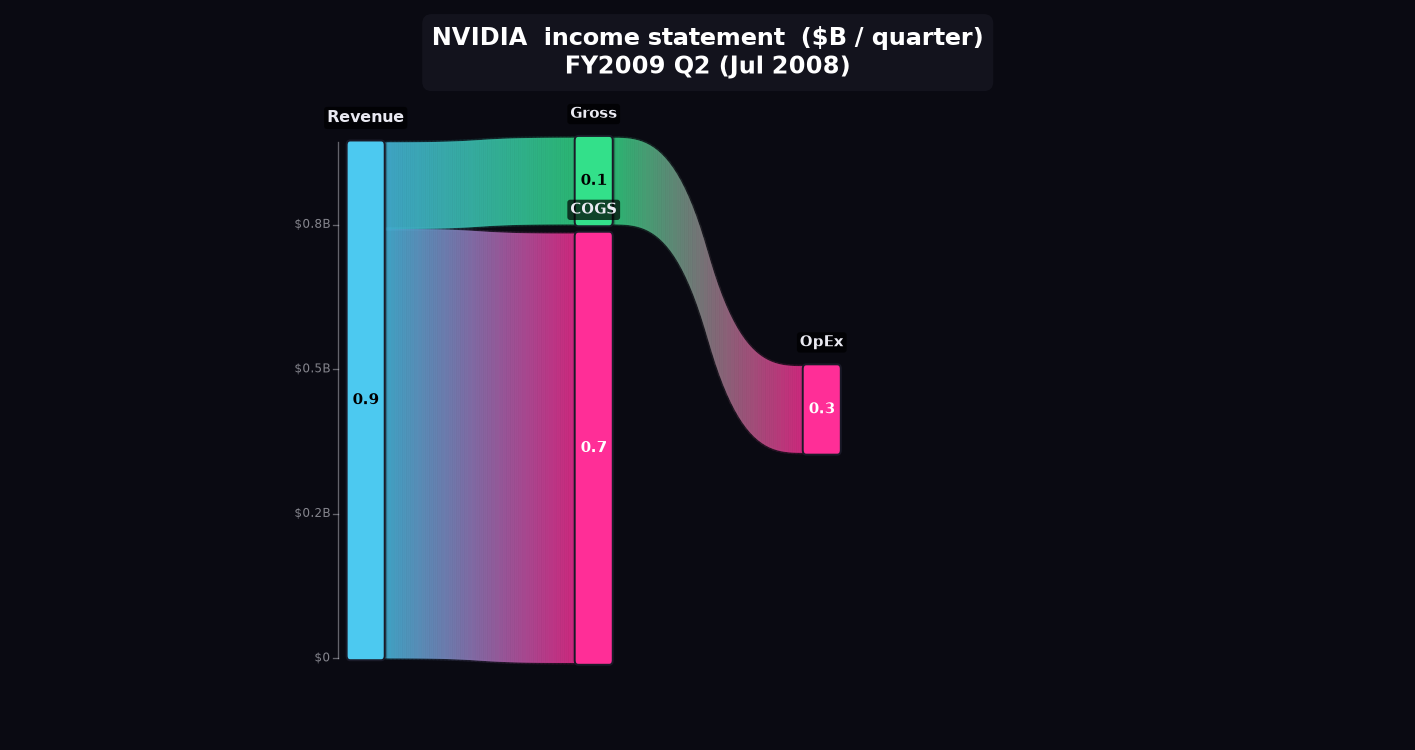

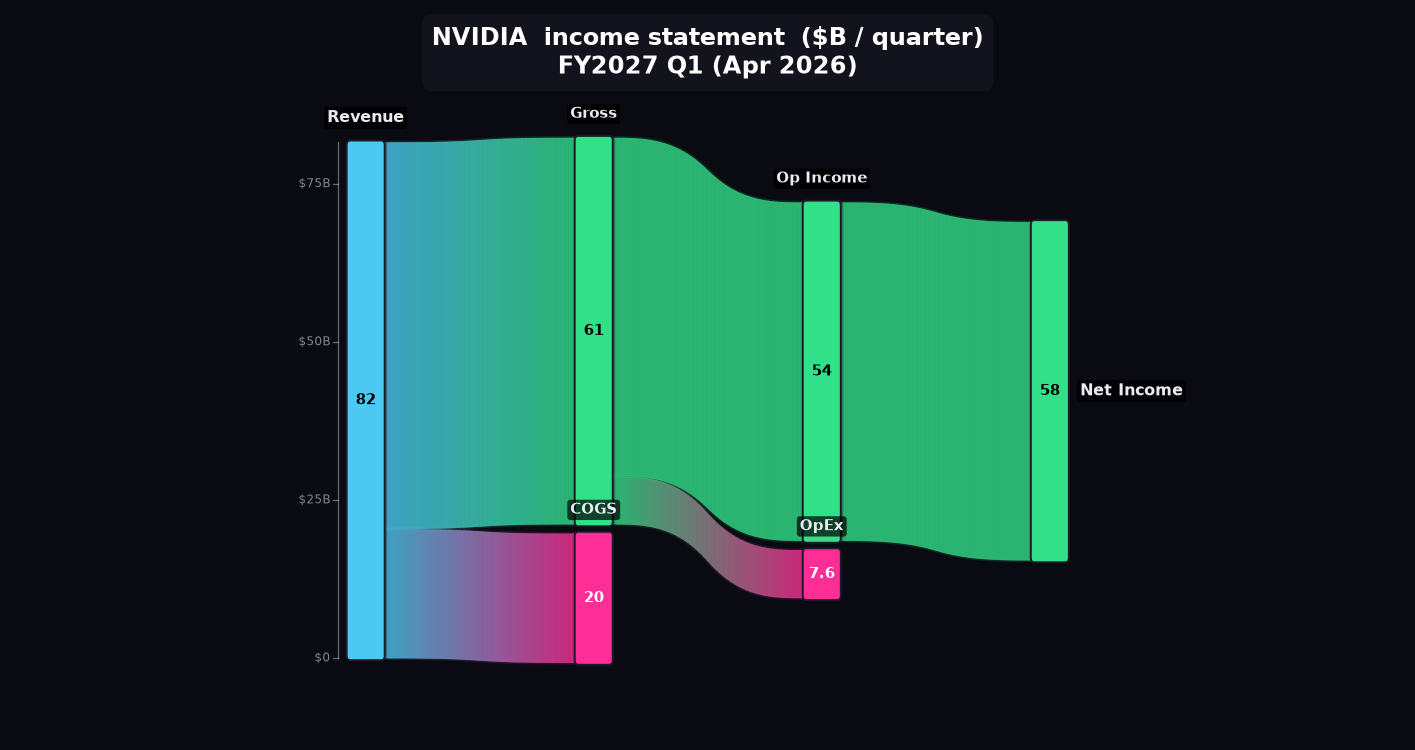

In [16]:
# Two contrasting quarters as stills.
loss_idx = next((i for i, q in enumerate(order) if by_q[q]["op_income"] < 0), 0)
still_paths = []
for tag, idx in [("loss", loss_idx), ("latest", len(order) - 1)]:
    q = order[idx]
    p = os.path.join(ASSETS, f"nvidia_{tag}.png")
    sankey.save_frame(
        p, frame_index=idx,
        title="NVIDIA  income statement  ($B / quarter)",
        figsize=(15, 8), dpi=95, font_size=12, title_fontsize=18, padding=2.4,
        theme="dark", link_glow=1, link_alpha=0.5,
        ranking_mode=False, stacked_mode=True,
        node_value_labels=labels_per_frame[idx],
        yaxis_node="Revenue", yaxis_suffix="B",
    )
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))


Now **one short clip**. We animate just the **last ~10 quarters** for a few seconds so
it renders fast, but with the *full* NVIDIA design — dark theme, glow, the `$` axis,
the accounting labels, and the stock overlay. (Rendering needs **FFmpeg** on your
system; if it's missing, this cell will raise — that's expected, and the stills above
already prove the look.)


In [17]:
# A short proof clip: last ~10 quarters, ~4 seconds. Full design, small scope.
N_TAIL = 10
tail = order[-N_TAIL:]
flows_tail = flows[flows["quarter"].isin(tail)].reset_index(drop=True)
labels_tail = labels_per_frame[-N_TAIL:]
overlay_tail = overlay[-N_TAIL:] if overlay else None
xlabels_tail = [q.split()[0] for q in tail]          # year ticks on the overlay x-axis

sk_tail = Sankey.from_dataframe(
    df=flows_tail, layers=LAYERS,
    time_col="quarter", source_col="source", target_col="target", value_col="value",
    node_colors=node_colors,
)

clip = os.path.join(ASSETS, "nvidia_income_proof.mp4")
kw = dict(
    title="NVIDIA  income statement  ($B / quarter)",
    figsize=(16, 9), fps=30, duration_seconds=4.0, quality="medium",
    font_size=12, title_fontsize=20, padding=2.4,
    margin_top=0.17, margin_bottom=0.20,
    theme="dark", link_glow=1, link_alpha=0.5,
    ranking_mode=False, stacked_mode=True, absolute_scale=False,
    node_value_labels_per_frame=labels_tail,
    yaxis_node="Revenue", yaxis_suffix="B",
    n_workers=2,
)
if overlay_tail and any(v == v for v in overlay_tail):
    kw.update(overlay_series=overlay_tail, overlay_x_labels=xlabels_tail,
              overlay_label="NVDA stock  ($, split-adj.)",
              overlay_color="#7CFF6B", overlay_badge="NVDA")

try:
    sk_tail.animate(output_path=clip, **kw)
    print("rendered:", clip)
except Exception as e:
    print("animate() needs FFmpeg on PATH; stills above already prove the look.")
    print("error was:", e)

Settings (MULTI-LAYER PARALLEL):
  - Layers: 4
  - Nodes per layer: [1, 2, 2, 2]
  - FPS: 30, Duration: 4.0s
  - Quality: medium
  - Total frames: 120
  - Gradient segments: 50
  - Positioning mode: Stacked
  - Dynamic color mode: Static

Pre-computing 120 frames...
  Pre-computation: 0.00s
  Workers: 2

Rendering on 2 parallel processes...


  Parallel rendering: 102.50s (1.2 fps)

Concatenating 2 chunks...


  Concatenation: 0.95s

Animation saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\nvidia_income_proof.mp4
Total time: 103.50s (1.2 effective fps)
rendered: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\nvidia_income_proof.mp4


In [18]:
# If the clip rendered, show it inline.
from IPython.display import Video
if os.path.exists(clip) and os.path.getsize(clip) > 0:
    display(Video(clip, embed=True, width=820))
else:
    print("No clip on disk (FFmpeg likely missing) — see the stills above.")


### The full reel — one line

Everything above is the long-hand. To render the **complete history** at full quality,
you just re-use the exact objects we already built — the tidy `flows`, the `LAYERS`,
the per-frame `labels_per_frame`, and the `overlay` — and hand them to `animate` once,
with no tail-slicing and a longer duration:

```python
# Uses flows / LAYERS / node_colors / labels_per_frame / overlay from above.
from datetime import datetime
stamp = datetime.now().strftime("%Y-%m-%d-%Hh%M")        # sortable, big-endian
out_mp4 = os.path.join(ASSETS, f"{stamp}_reel_NVDA.mp4")  # filename starts with the date

full = Sankey.from_dataframe(
    df=flows, layers=LAYERS,
    time_col="quarter", source_col="source", target_col="target", value_col="value",
    node_colors=node_colors,
)
kw = dict(
    title="NVIDIA  income statement  ($B / quarter)",
    figsize=(16, 9), fps=30, duration_seconds=45, quality="high",
    font_size=12, title_fontsize=20, padding=2.4,
    margin_top=0.17, margin_bottom=0.20,
    theme="dark", link_glow=1, link_alpha=0.5,
    ranking_mode=False, stacked_mode=True, absolute_scale=False,
    node_value_labels_per_frame=labels_per_frame,
    yaxis_node="Revenue", yaxis_suffix="B", n_workers=2,
)
if overlay and any(v == v for v in overlay):
    kw.update(overlay_series=overlay,
              overlay_x_labels=[q.split()[0] for q in order],
              overlay_label="NVDA stock  ($, split-adj.)",
              overlay_color="#7CFF6B", overlay_badge="NVDA")
full.animate(output_path=out_mp4, **kw)     # needs FFmpeg on PATH
```

We prefix the filename with a sortable `%Y-%m-%d-%Hh%M` stamp (e.g.
`2026-06-11-14h30_reel_NVDA.mp4`) so renders sort chronologically on disk.



## 9. Recap & try it yourself

**What we did, end to end:**
1. Resolved `NVDA → CIK 0001045810` via the SEC ticker map.
2. Pulled four robust US-GAAP concepts from the **companyconcept** API.
3. Cleaned the mess: **merged revenue tags**, **derived fiscal Q4** from the YTD,
   kept the latest-filed figure per period.
4. Derived the cost leaks as residuals and **balanced loss quarters** with a clamp.
5. Built the tidy `[quarter, source, target, value]` frame + colors + layers.
6. Drove `from_dataframe → save_frame / animate` with the full NVIDIA design.

> **From NVIDIA-specific to generic.** The inline code above is tuned for NVIDIA,
> but the same recipe generalises to **any US filer**. To support other tickers
> cleanly you'd add a 3rd revenue tag (`SalesRevenueNet`, which filers like AAPL
> used pre-ASC-606) and a `COGS → GrossProfit` fallback (deriving gross profit as
> revenue − COGS when a filer doesn't tag it directly), so other companies don't
> lose their early history. Exercise 1 below walks you through the first step.

### Exercises

- **Another ticker.** Swap `cik_for("NVDA")` for `cik_for("AMD")` or `cik_for("AAPL")`
  and re-run. For AAPL you'll want to extend `REVENUE_TAGS` with `SalesRevenueNet`
  (the pre-ASC-606 tag) so its early history isn't lost.
- **Annual view.** Aggregate four quarters into fiscal years before building flows.
- **Recolor.** Try `dynamic_color_mode="intensity"` so the chart *lights up* as the
  company grows, instead of fixed green/magenta.
- **Your own music.** Pass `audio_url="https://youtu.be/..."` + `audio_start=...` to
  `animate` (needs the `[audio]` extra / yt-dlp).
- **A COGS fallback.** Some filers tag `CostOfGoodsSold` instead of `CostOfRevenue`,
  or don't tag `GrossProfit` at all — derive it as `revenue − cogs` and your
  pipeline covers far more companies.

### Links
- **Repo:** https://github.com/FG-SC/gradient-sankey  ·  `pip install gradient-sankey`
- **SEC EDGAR API:** https://www.sec.gov/edgar/sec-api-documentation
- **SEC `companyconcept` for NVDA:**
  https://data.sec.gov/api/xbrl/companyconcept/CIK0001045810/us-gaap/Revenues.json (needs a User-Agent)
- **Companion tutorials:** `notebooks/09_tutorial_bigtech_amazon.ipynb` and
  `notebooks/11_tutorial_alphabet.ipynb` (the same SEC P&L world, company-wide).

---
*Obrigado por chegar até aqui. Bem-vindo à comunidade — build something beautiful.*
*Data: SEC EDGAR (XBRL) & Yahoo Finance. Built with Python, NumPy, Matplotlib, FFmpeg.*
